# Imports and Setup

In [ ]:
# Cell 1: Install Ultralytics
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "--upgrade", "pip", "-q"], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "ultralytics", "pyyaml", "-q"], check=True)
print("Ultralytics installed.")

Ultralytics installed.


In [ ]:
# Cell 2: Core Imports
import os
import json
import random
from pathlib import Path

import cv2
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch

from ultralytics import YOLO

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

### GPU Check

In [ ]:
# Cell 3: Verify GPU
gpu_available = torch.cuda.is_available()
device_name = torch.cuda.get_device_name(0) if gpu_available else "CPU"
compute_device = "cuda" if gpu_available else "cpu"

print(f"GPU available : {gpu_available}")
print(f"Active device : {device_name}")

GPU available : True
Active device : Quadro RTX 4000


# Path Configuration

In [ ]:
# Cell 4: Project Paths
project_root = Path("/home/vteam5/multispectral_pedestrian_ensemble")
processed_dataset_dir = project_root / "processed_dataset"
detection_results_dir = project_root / "results_detection"
detection_results_dir.mkdir(parents=True, exist_ok=True)

data_yaml_path = processed_dataset_dir / "data.yaml"

if not data_yaml_path.exists():
    raise FileNotFoundError(f"data.yaml not found at {data_yaml_path}. Run Member 1's preprocessing first.")

with open(data_yaml_path) as f:
    data_config = yaml.safe_load(f)

print("data.yaml contents:")
for k, v in data_config.items():
    print(f"  {k}: {v}")

n_train = len(list((processed_dataset_dir / "train" / "images").glob("*.jpg")))
n_val = len(list((processed_dataset_dir / "val" / "images").glob("*.jpg")))
print(f"\nTraining images   : {n_train}")
print(f"Validation images : {n_val}")

data.yaml contents:
  path: /home/vteam5/multispectral_pedestrian_ensemble/processed_dataset
  train: train/images
  val: val/images
  nc: 1
  names: ['Pedestrian']

Training images   : 10221
Validation images : 1804


### Hyperparameters

In [ ]:
# Cell 5: YOLO Hyperparameters (per Member 1 spec)
# Model
yolo_model = "yolo11s.pt"
img_size = 1024
epochs = 50
batch_size = 8
patience = 10
workers = 8
lr0 = 0.01

# Inference
conf_default = 0.25
nms_iou = 0.45
max_det = 100

# Augmentation: geometric only (HSV disabled — thermal R-channel is not red)
hsv_h = 0.0
hsv_s = 0.0
hsv_v = 0.0
fliplr = 0.5
flipud = 0.0
degrees = 0.0
translate = 0.10
scale = 0.50
mosaic = 1.0
close_mosaic = 10

run_name = "member2_yolo11s_thermal_pedestrian"
print("Hyperparameters set.")

Hyperparameters set.


# Training

### Load or Train YOLOv11s

In [ ]:
# Cell 6: Locate trained checkpoint (skip retraining if it exists)
# Team's existing trained checkpoint from Member 3's pipeline run
existing_checkpoint = Path(
    "/home/vteam5/multispectral_pedestrian_ensemble/results/"
    "pedestrian_multispectral_yolo11s/weights/best.pt"
)

if existing_checkpoint.exists():
    best_checkpoint_path = existing_checkpoint
    print(f"Using existing trained checkpoint: {best_checkpoint_path}")
    print(f"Size: {best_checkpoint_path.stat().st_size / 1e6:.1f} MB")
else:
    print("No existing checkpoint found — training from scratch.")
    print("Set 'do_train' = True in the next cell to train.")
    best_checkpoint_path = (
        detection_results_dir / run_name / "weights" / "best.pt"
    )

Using existing trained checkpoint: /home/vteam5/multispectral_pedestrian_ensemble/results/pedestrian_multispectral_yolo11s/weights/best.pt
Size: 19.3 MB


In [ ]:
# Cell 7: Train (only if no existing checkpoint)
do_train = not best_checkpoint_path.exists()

if do_train:
    model = YOLO(yolo_model)
    results = model.train(
        data=str(data_yaml_path),
        imgsz=img_size,
        epochs=epochs,
        batch=batch_size,
        lr0=lr0,
        iou=nms_iou,
        conf=conf_default,
        patience=patience,
        workers=workers,
        hsv_h=hsv_h, hsv_s=hsv_s, hsv_v=hsv_v,
        fliplr=fliplr, flipud=flipud, degrees=degrees,
        translate=translate, scale=scale,
        mosaic=mosaic, close_mosaic=close_mosaic,
        name=run_name,
        project=str(detection_results_dir),
        device=compute_device,
        verbose=True
    )
    print(f"Training complete. Best: {best_checkpoint_path}")
else:
    print("Skipping training — using existing checkpoint.")

Skipping training — using existing checkpoint.


### Training Curves

Loaded 50 epochs from /home/vteam5/multispectral_pedestrian_ensemble/results/pedestrian_multispectral_yolo11s/results.csv


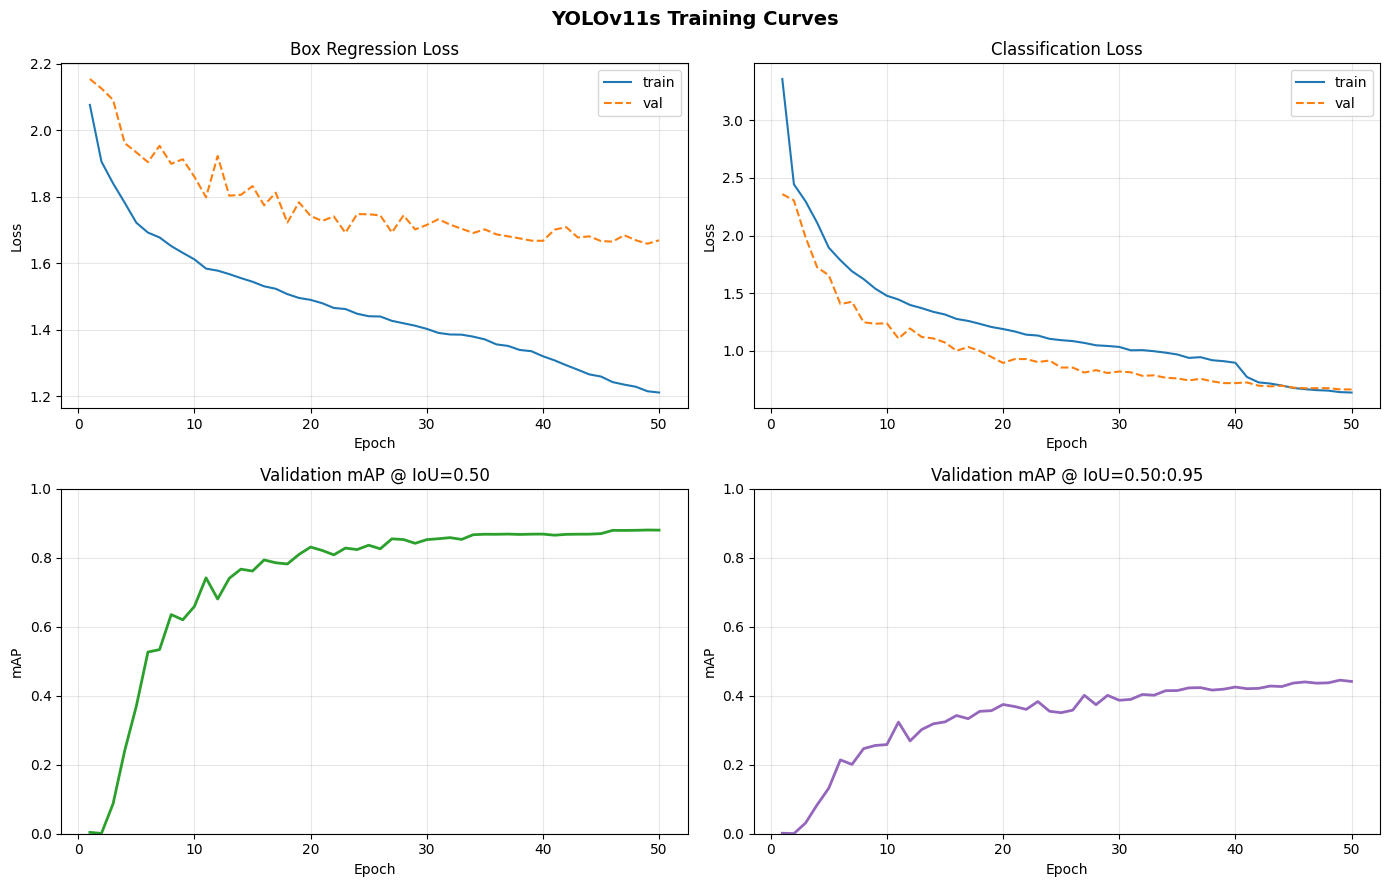


Final epoch (50) metrics:
  train/box_loss              : 1.2115
  metrics/mAP50(B)            : 0.8803
  metrics/mAP50-95(B)         : 0.4415
  metrics/precision(B)        : 0.9286
  metrics/recall(B)           : 0.8875


In [ ]:
# Cell 8: Plot training curves from results.csv
# Look in either the new run folder or the existing one
candidate_csv_paths = [
    detection_results_dir / run_name / "results.csv",
    Path("/home/vteam5/multispectral_pedestrian_ensemble/results/"
         "pedestrian_multispectral_yolo11s/results.csv"),
]
results_csv = next((p for p in candidate_csv_paths if p.exists()), None)

if results_csv is None:
    print("results.csv not found — skipping curves.")
else:
    df = pd.read_csv(results_csv)
    df.columns = [c.strip() for c in df.columns]
    print(f"Loaded {len(df)} epochs from {results_csv}")

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle("YOLOv11s Training Curves", fontsize=14, fontweight="bold")
    epochs_axis = df["epoch"]

    if "train/box_loss" in df.columns:
        axes[0, 0].plot(epochs_axis, df["train/box_loss"], label="train", color="tab:blue")
        if "val/box_loss" in df.columns:
            axes[0, 0].plot(epochs_axis, df["val/box_loss"], label="val", color="tab:orange", linestyle="--")
        axes[0, 0].set_title("Box Regression Loss")
        axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
        axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

    if "train/cls_loss" in df.columns:
        axes[0, 1].plot(epochs_axis, df["train/cls_loss"], label="train", color="tab:blue")
        if "val/cls_loss" in df.columns:
            axes[0, 1].plot(epochs_axis, df["val/cls_loss"], label="val", color="tab:orange", linestyle="--")
        axes[0, 1].set_title("Classification Loss")
        axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Loss")
        axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

    if "metrics/mAP50(B)" in df.columns:
        axes[1, 0].plot(epochs_axis, df["metrics/mAP50(B)"], color="tab:green", linewidth=2)
        axes[1, 0].set_title("Validation mAP @ IoU=0.50")
        axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("mAP")
        axes[1, 0].set_ylim(0, 1); axes[1, 0].grid(alpha=0.3)

    if "metrics/mAP50-95(B)" in df.columns:
        axes[1, 1].plot(epochs_axis, df["metrics/mAP50-95(B)"], color="tab:purple", linewidth=2)
        axes[1, 1].set_title("Validation mAP @ IoU=0.50:0.95")
        axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("mAP")
        axes[1, 1].set_ylim(0, 1); axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(detection_results_dir / "training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

    final = df.iloc[-1]
    print(f"\nFinal epoch ({int(final['epoch'])}) metrics:")
    for col in ["train/box_loss", "metrics/mAP50(B)", "metrics/mAP50-95(B)",
                "metrics/precision(B)", "metrics/recall(B)"]:
        if col in df.columns:
            print(f"  {col:<28}: {final[col]:.4f}")

# Confidence Threshold Tuning

### Sweep across thresholds for thermal heat signatures

Lower thresholds catch faint signatures from insulated clothing, thermal inversion on hot pavement, and visible-channel washout. False positives from low thresholds are filtered later by the SAM 2 Veto Mechanism.

In [ ]:
# Cell 9: IoU helper + ground truth loader
def box_iou(a, b):
    x1, y1 = max(a[0], b[0]), max(a[1], b[1])
    x2, y2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    union = (a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter
    return inter / union if union > 0 else 0

def load_gt(label_path, size):
    if not label_path.exists():
        return []
    boxes = []
    for line in label_path.read_text().strip().split("\n"):
        if not line.strip(): continue
        parts = [float(v) for v in line.split()]
        if len(parts) < 5: continue
        cx, cy, w, h = parts[1:5]
        boxes.append([(cx - w/2)*size, (cy - h/2)*size, (cx + w/2)*size, (cy + h/2)*size])
    return boxes

In [ ]:
# Cell 10: Run threshold sweep
model = YOLO(str(best_checkpoint_path))
val_images = sorted((processed_dataset_dir / "val" / "images").glob("*.jpg"))
val_labels_dir = processed_dataset_dir / "val" / "labels"

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]
records = []

for conf in thresholds:
    tp = fp = fn = 0
    total_dets = 0
    print(f"  conf={conf:.2f} ...", end="", flush=True)

    for img_path in val_images:
        gt = load_gt(val_labels_dir / (img_path.stem + ".txt"), img_size)
        pred = model.predict(source=str(img_path), conf=conf, iou=nms_iou,
                             imgsz=img_size, verbose=False)
        boxes = pred[0].boxes.xyxy.cpu().numpy().tolist()
        total_dets += len(boxes)

        matched = [False] * len(gt)
        for b in boxes:
            best_iou, best_idx = 0, -1
            for i, g in enumerate(gt):
                if matched[i]: continue
                v = box_iou(b, g)
                if v > best_iou:
                    best_iou, best_idx = v, i
            if best_iou >= 0.5:
                tp += 1; matched[best_idx] = True
            else:
                fp += 1
        fn += matched.count(False)

    p = tp / (tp + fp) if (tp + fp) > 0 else 0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2*p*r / (p + r) if (p + r) > 0 else 0
    records.append({"conf": conf, "TP": tp, "FP": fp, "FN": fn,
                    "precision": p, "recall": r, "f1": f1,
                    "det_per_img": total_dets / len(val_images)})
    print(f"  P={p:.3f}  R={r:.3f}  F1={f1:.3f}  det/img={total_dets/len(val_images):.2f}")

sweep_df = pd.DataFrame(records)
sweep_df.to_csv(detection_results_dir / "confidence_sweep.csv", index=False)
print("\n", sweep_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

  conf=0.10 ...  P=0.673  R=0.729  F1=0.700  det/img=3.03
  conf=0.15 ...  P=0.725  R=0.727  F1=0.726  det/img=2.81
  conf=0.20 ...  P=0.761  R=0.724  F1=0.742  det/img=2.67
  conf=0.25 ...  P=0.793  R=0.721  F1=0.755  det/img=2.55
  conf=0.30 ...  P=0.818  R=0.716  F1=0.764  det/img=2.45
  conf=0.35 ...  P=0.847  R=0.709  F1=0.772  det/img=2.34
  conf=0.40 ...  P=0.879  R=0.702  F1=0.781  det/img=2.24
  conf=0.50 ...  P=0.929  R=0.676  F1=0.782  det/img=2.04

   conf   TP   FP   FN  precision  recall     f1  det_per_img
0.1000 3686 1789 1371     0.6732  0.7289 0.7000       3.0349
0.1500 3674 1397 1383     0.7245  0.7265 0.7255       2.8110
0.2000 3659 1151 1398     0.7607  0.7236 0.7417       2.6663
0.2500 3644  951 1413     0.7930  0.7206 0.7551       2.5471
0.3000 3619  803 1438     0.8184  0.7156 0.7636       2.4512
0.3500 3584  645 1473     0.8475  0.7087 0.7719       2.3442
0.4000 3551  490 1506     0.8787  0.7022 0.7806       2.2400
0.5000 3418  263 1639     0.9286  0.6759 0.782

### Plot sweep results

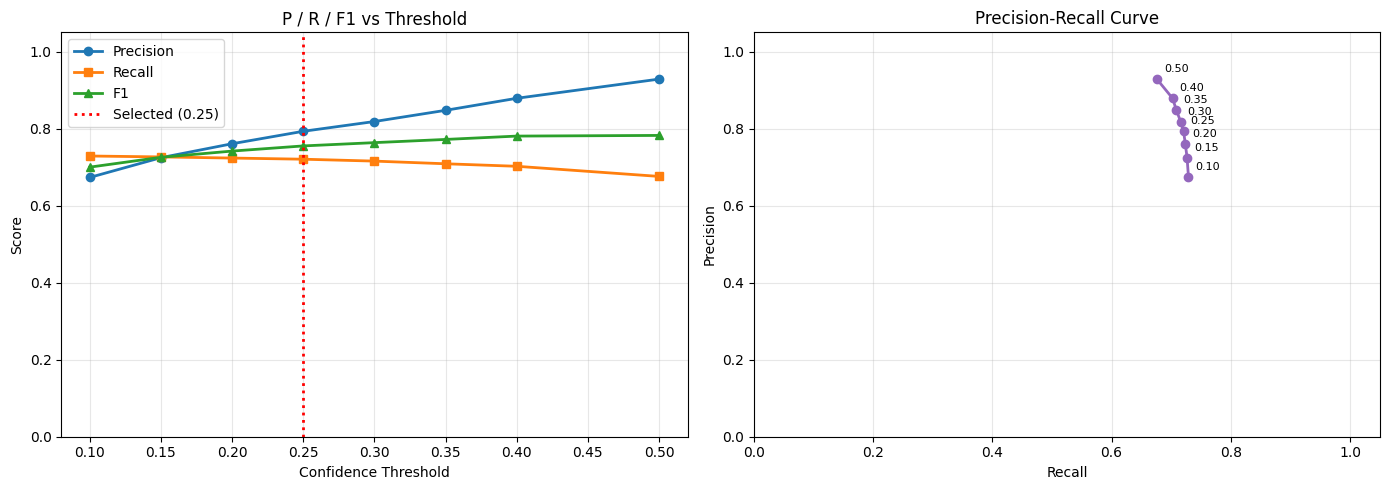


Recommended threshold for SAM 2 cascade: 0.30


In [ ]:
# Cell 11: P/R/F1 vs threshold + PR curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(sweep_df["conf"], sweep_df["precision"], "o-", label="Precision", linewidth=2)
axes[0].plot(sweep_df["conf"], sweep_df["recall"], "s-", label="Recall", linewidth=2)
axes[0].plot(sweep_df["conf"], sweep_df["f1"], "^-", label="F1", linewidth=2)
axes[0].axvline(0.25, color="red", linestyle=":", linewidth=2, label="Selected (0.25)")
axes[0].set_xlabel("Confidence Threshold"); axes[0].set_ylabel("Score")
axes[0].set_title("P / R / F1 vs Threshold")
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_ylim(0, 1.05)

axes[1].plot(sweep_df["recall"], sweep_df["precision"], "o-", color="tab:purple", linewidth=2)
for _, row in sweep_df.iterrows():
    axes[1].annotate(f"{row['conf']:.2f}", (row["recall"], row["precision"]),
                     fontsize=8, xytext=(5, 5), textcoords="offset points")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].grid(alpha=0.3); axes[1].set_xlim(0, 1.05); axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(detection_results_dir / "confidence_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

# Recommended operating point: lowest threshold within 0.02 F1 of the best
best_f1 = sweep_df["f1"].max()
candidates = sweep_df[sweep_df["f1"] >= best_f1 - 0.02]
selected = float(candidates["conf"].min())
print(f"\nRecommended threshold for SAM 2 cascade: {selected:.2f}")

# Validation

In [ ]:
# Cell 12: Run model.val() for official mAP metrics
val_model = YOLO(str(best_checkpoint_path))
metrics = val_model.val(
    data=str(data_yaml_path),
    imgsz=img_size,
    conf=conf_default,
    iou=nms_iou,
    device=compute_device
)

map50 = float(metrics.box.map50)
map50_95 = float(metrics.box.map)
precision = float(metrics.box.mp)
recall = float(metrics.box.mr)

print("\n" + "=" * 50)
print("  YOLO-Only Validation Results")
print("=" * 50)
print(f"  mAP@50       : {map50:.4f}")
print(f"  mAP@50-95    : {map50_95:.4f}")
print(f"  Precision    : {precision:.4f}")
print(f"  Recall       : {recall:.4f}")
print("=" * 50)

# Save for Member 3
with open(detection_results_dir / "yolo_baseline_metrics.json", "w") as f:
    json.dump({
        "model": yolo_model,
        "image_size": img_size,
        "confidence_threshold": conf_default,
        "iou_threshold_nms": nms_iou,
        "mAP_at_0.50": map50,
        "mAP_at_0.50_to_0.95": map50_95,
        "precision": precision,
        "recall": recall,
    }, f, indent=2)

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.6.0+cu124 CUDA:0 (Quadro RTX 4000, 7974MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 8035.9±1309.2 MB/s, size: 279.1 KB)
val: Scanning /home/vteam5/multispectral_pedestrian_ensemble/processed_dataset/val/labels.cache... 1804 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1804/1804 540.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 113/113 3.4it/s 33.0s
                   all       1804       5057      0.927      0.888      0.881      0.445
Speed: 1.2ms preprocess, 14.9ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /home/vteam5/runs/detect/val

  YOLO-Only Validation Results
  mAP@50       : 0.8805
  mAP@50-95    : 0.4449
  Precision    : 0.9268
  Recall       : 0.8877


# Qualitative Samples

In [ ]:
# Cell 13: 6-image grid — predictions vs ground truth
sample_indices = random.sample(range(len(val_images)), 6)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("YOLOv11s Predictions on Fused IR+Visible Input\n"
             "(Red = prediction with confidence | Green dashed = ground truth)",
             fontsize=12, fontweight="bold")
axes_flat = axes.flatten()

q_model = YOLO(str(best_checkpoint_path))

for pos, idx in enumerate(sample_indices):
    img_path = val_images[idx]
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)

    pred = q_model.predict(source=str(img_path), conf=conf_default, iou=nms_iou,
                           imgsz=img_size, verbose=False)
    boxes = pred[0].boxes.xyxy.cpu().numpy()
    confs = pred[0].boxes.conf.cpu().numpy()
    gt = load_gt(val_labels_dir / (img_path.stem + ".txt"), img_size)

    axes_flat[pos].imshow(img)
    for g in gt:
        rect = patches.Rectangle((g[0], g[1]), g[2]-g[0], g[3]-g[1],
                                 linewidth=2, edgecolor="lime", linestyle="--", facecolor="none")
        axes_flat[pos].add_patch(rect)
    for b, c in zip(boxes, confs):
        rect = patches.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1],
                                 linewidth=2, edgecolor="red", facecolor="none")
        axes_flat[pos].add_patch(rect)
        axes_flat[pos].text(b[0], b[1]-5, f"{c:.2f}", color="red",
                            fontsize=8, fontweight="bold")
    axes_flat[pos].set_title(f"{img_path.name} — {len(boxes)} det / {len(gt)} GT", fontsize=10)
    axes_flat[pos].axis("off")

plt.tight_layout()
plt.savefig(detection_results_dir / "qualitative_samples.png", dpi=150, bbox_inches="tight")
plt.show()

# Bridge Export to SAM 2

### Save bbox detections in xyxy absolute pixels

Output keyed by image filename, ready for `SAM2ImagePredictor.predict(box=...)`.

In [ ]:
# Cell 14: Export yolo_detections.json for Member 1's SAM 2 stage
export_model = YOLO(str(best_checkpoint_path))
export_dict = {
    "metadata": {
        "model": yolo_model,
        "checkpoint_path": str(best_checkpoint_path),
        "image_size": img_size,
        "confidence_threshold": conf_default,
        "iou_threshold_nms": nms_iou,
        "max_detections": max_det,
        "format": "xyxy_absolute_pixels",
        "num_images": len(val_images),
    },
    "detections": {}
}

total = 0
zero_count = 0
for i, img_path in enumerate(val_images):
    out = export_model.predict(source=str(img_path), conf=conf_default, iou=nms_iou,
                               imgsz=img_size, max_det=max_det, verbose=False)
    boxes = out[0].boxes.xyxy.cpu().numpy()
    confs = out[0].boxes.conf.cpu().numpy()

    export_dict["detections"][img_path.name] = {
        "image_size_hw": [img_size, img_size],
        "boxes_xyxy": boxes.round(2).tolist(),
        "confidences": confs.round(4).tolist(),
    }
    total += len(boxes)
    if len(boxes) == 0: zero_count += 1
    if (i + 1) % 200 == 0:
        print(f"  {i+1}/{len(val_images)} | {total} detections so far")

bridge_path = detection_results_dir / "yolo_detections.json"
with open(bridge_path, "w") as f:
    json.dump(export_dict, f, indent=2)

print("\n" + "=" * 60)
print("  Bridge Export Complete")
print("=" * 60)
print(f"  Images          : {len(val_images)}")
print(f"  Detections      : {total}")
print(f"  Zero-detection  : {zero_count}")
print(f"  Avg det/img     : {total/len(val_images):.2f}")
print(f"  Output          : {bridge_path}")
print(f"  File size       : {bridge_path.stat().st_size/1e6:.2f} MB")

### Loading snippet for Member 1's SAM 2 stage

```python
import json, numpy as np
with open("yolo_detections.json") as f:
    bridge = json.load(f)

# For one image
rec = bridge["detections"]["010001.jpg"]
boxes = np.array(rec["boxes_xyxy"])

sam2_predictor.set_image(fused_rgb)
masks, iou, _ = sam2_predictor.predict(
    point_coords=None, point_labels=None,
    box=boxes, multimask_output=False
)
```

# Summary

In [ ]:
# Cell 15: Print final summary and saved artefacts
print("\n" + "#" * 60)
print("  MEMBER 2 — YOLO DETECTION COMPLETE")
print("#" * 60)
print(f"\n  Model          : {yolo_model}")
print(f"  Image size     : {img_size}")
print(f"  Confidence     : {conf_default}")
print(f"  NMS IoU        : {nms_iou}")
print(f"\n  mAP@50         : {map50:.4f}")
print(f"  mAP@50-95      : {map50_95:.4f}")
print(f"  Precision      : {precision:.4f}")
print(f"  Recall         : {recall:.4f}")

print("\n  Saved artefacts:")
for p in sorted(detection_results_dir.rglob("*")):
    if p.is_file() and p.suffix in (".csv", ".json", ".png"):
        print(f"    {p.relative_to(detection_results_dir)}  ({p.stat().st_size/1e6:.2f} MB)")